# do-Shapley: Causal Contributions via do-interventions

This notebook demonstrates the `DoCausalImputer` which implements causal Shapley values based on the paper:

> **"On Measuring Causal Contributions via do-interventions"** (Jung, Tian, & Bareinboim, ICML 2022)

## Key Concepts

### Standard SHAP vs Causal SHAP vs do-Shapley

| Method | Value Function | Handles Confounding | Input |
|--------|---------------|---------------------|-------|
| Standard SHAP | $\mathbb{E}[Y \mid X_S = x_S]$ (conditional) | No | None |
| Causal SHAP | Conditional with causal ordering | Partial | Ordering + Confounding |
| **do-Shapley** | $\mathbb{E}[Y \mid do(X_S = x_S)]$ (interventional) | Yes | DAG (edges) |

### do-intervention

The `do(X=x)` operator:
- **Cuts** all incoming edges to X in the causal graph
- **Sets** X to value x
- Removes spurious correlations through confounders

## Dataset: Bike Sharing Daily

We use the UCI Bike Sharing Dataset (daily aggregates, 731 samples) - the same dataset used in Heskes et al. (2020) - with a realistic causal DAG structure.

## Reference
- Paper: https://proceedings.mlr.press/v162/jung22a.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

import shapiq
from shapiq import TabularExplainer
from shapiq.imputer import DoCausalImputer  # needed for DoCausalImputer.confounding_group()
from shapiq.datasets import load_bike_sharing_daily, load_bike_sharing_daily_train_index
from shapiq.plot import network_plot

print(f"shapiq version: {shapiq.__version__}")

e:\Desktop\Shapley\Shapiq\shapiq\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shapiq version: None


## 1. Load and Preprocess Bike Sharing Daily Data

We load the UCI Bike Sharing Dataset (daily aggregates, 731 samples) and extract features for our causal DAG:

Features used:
- **trend**: Days since start (computed from dteday)
- **sinyear**: sin(2π × trend / 365) - cyclical season proxy
- **weekday**: Day of week (0-6)
- **location**: Constant 1 (placeholder for location effect)
- **workingday**: Whether it's a working day
- **holiday**: Whether it's a holiday
- **weather**: Weather situation (1-4)
- **temp**: Temperature (unnormalized)
- **humidity**: Humidity (unnormalized)
- **windspeed**: Wind speed (unnormalized)
- **feel_temp**: Feeling temperature (atemp, unnormalized)

In [2]:
# Load preprocessed bike sharing daily data (contains trend, sinyear, etc.)
# and also raw data for additional features
x_preprocessed, y_data = load_bike_sharing_daily(preprocessed=True)
x_raw, _ = load_bike_sharing_daily(preprocessed=False)
train_idx = load_bike_sharing_daily_train_index()

print(f"Preprocessed data columns: {x_preprocessed.columns.tolist()}")
print(f"Raw data columns: {x_raw.columns.tolist()}")
print(f"Data shape: {x_preprocessed.shape[0]} samples")

# Create combined dataframe with all needed features
x_data_raw = x_preprocessed.copy()

# Add raw features we need (not in preprocessed)
x_data_raw['weekday'] = x_raw['weekday'].values
x_data_raw['workingday'] = x_raw['workingday'].values
x_data_raw['holiday'] = x_raw['holiday'].values
x_data_raw['weather'] = x_raw['weathersit'].values

# Add location constant (placeholder)
x_data_raw['location'] = 1.0

# Rename for clarity
x_data_raw.rename(columns={
    'hum': 'humidity',
    'atemp': 'feel_temp'
}, inplace=True)

print(f"\nCombined data columns: {x_data_raw.columns.tolist()}")
print(f"Trend range: [{x_data_raw['trend'].min():.1f}, {x_data_raw['trend'].max():.1f}]")
print(f"Sinyear range: [{x_data_raw['sinyear'].min():.3f}, {x_data_raw['sinyear'].max():.3f}]")

Preprocessed data columns: ['trend', 'cosyear', 'sinyear', 'temp', 'atemp', 'windspeed', 'hum']
Raw data columns: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Data shape: 731 samples

Combined data columns: ['trend', 'cosyear', 'sinyear', 'temp', 'feel_temp', 'windspeed', 'humidity', 'weekday', 'workingday', 'holiday', 'weather', 'location']
Trend range: [0.0, 730.0]
Sinyear range: [-1.000, 1.000]


In [3]:
# Select features for our causal model (matching the original DAG structure)
# Feature order: trend, sinyear, weekday, location, workingday, holiday, weather, temp, humidity, windspeed, feel_temp

feature_names = [
    "trend",      # 0: Days since start
    "sinyear",    # 1: Seasonal cycle
    "weekday",    # 2: Day of week (0-6)
    "location",   # 3: Location (constant 1)
    "workingday", # 4: Is working day
    "holiday",    # 5: Is holiday
    "weather",    # 6: Weather condition (weathersit)
    "temp",       # 7: Temperature
    "humidity",   # 8: Humidity
    "windspeed",  # 9: Wind speed
    "feel_temp",  # 10: Feeling temperature (atemp)
]

# Prepare feature matrix (columns already exist in x_data_raw from previous cell)
x_data = x_data_raw[feature_names].copy()

# Create train/test split
all_idx = np.arange(len(x_data))
test_idx = np.array([i for i in all_idx if i not in train_idx])

# Prepare data with centering (as in original paper)
X_train = x_data.iloc[train_idx].values
y_train_nc = y_data.iloc[train_idx].values  # not centered
y_train_mean = y_train_nc.mean()
y_train = y_train_nc - y_train_mean  # centered

X_test = x_data.iloc[test_idx].values
y_test = y_data.iloc[test_idx].values - y_train_mean  # centered using train mean

n_features = len(feature_names)

print(f"Features ({len(feature_names)}): {feature_names}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train mean (μ₀): {y_train_mean:.2f}")

Features (11): ['trend', 'sinyear', 'weekday', 'location', 'workingday', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'feel_temp']
X_train shape: (587, 11)
X_test shape: (144, 11)
y_train mean (μ₀): 4505.03


### 1.2. Data Visualization: Bike Rentals Over Time

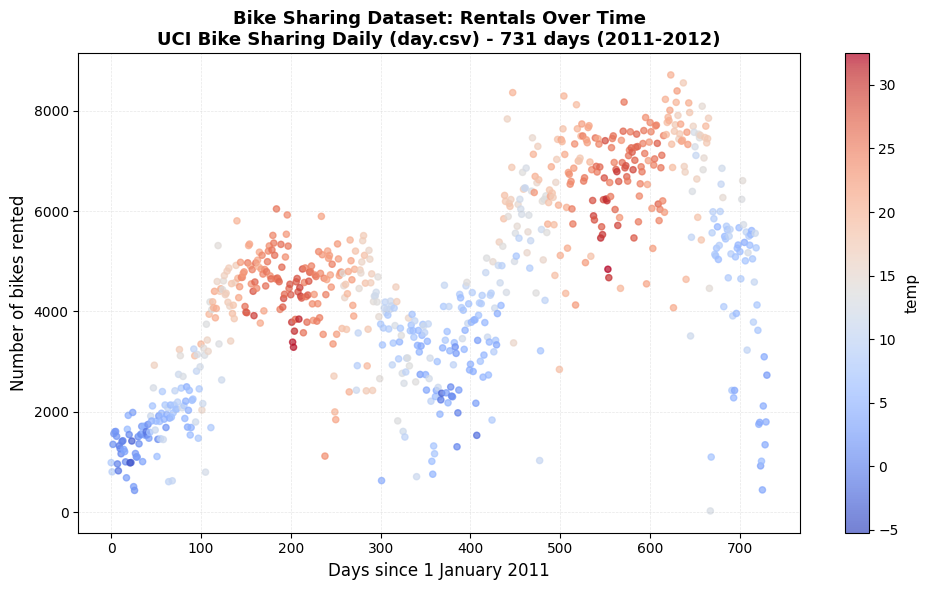


Data Patterns Observed:
1. TREND: Bike rentals generally increase over time (2011-2012)
2. SEASONALITY: Clear seasonal pattern with peaks in warm months
3. TEMPERATURE: Warmer days (red) tend to have more rentals
4. The correlation between temp and rentals is confounded by season


In [4]:
# Visualize: Number of bikes rented over time, colored by temperature
# This shows the raw data patterns before Shapley analysis

fig, ax = plt.subplots(figsize=(10, 6))

# Use full dataset for visualization (not centered)
trend_values = x_data['trend'].values
temp_values = x_data['temp'].values
y_values = y_data.values  # Original bike rental counts (not centered)

# Create scatter plot
scatter = ax.scatter(trend_values, y_values, c=temp_values, 
                     cmap='coolwarm', s=20, alpha=0.7)

ax.set_xlabel('Days since 1 January 2011', fontsize=12)
ax.set_ylabel('Number of bikes rented', fontsize=12)
ax.set_title('Bike Sharing Dataset: Rentals Over Time\n'
             'UCI Bike Sharing Daily (day.csv) - 731 days (2011-2012)', 
             fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('temp', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nData Patterns Observed:")
print("=" * 60)
print("1. TREND: Bike rentals generally increase over time (2011-2012)")
print("2. SEASONALITY: Clear seasonal pattern with peaks in warm months")
print("3. TEMPERATURE: Warmer days (red) tend to have more rentals")
print("4. The correlation between temp and rentals is confounded by season")
print("=" * 60)

## 2. Train XGBoost Model

In [5]:
# Train XGBoost model (same configuration as heskes paper reproduction)
model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=1,
    verbosity=0
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE (centered): {rmse:.2f}")

Test RMSE (centered): 728.97


## 3. Define Causal DAG Structure

The causal graph has two main pathways:

### Pathway 1: Calendar → Work Status → Count
```
[trend, weekday, location] → [workingday, holiday] → count
```

### Pathway 2: Environment → Weather/Temperature → Feel_temp → Count
```
[trend, location] → [sinyear, weather, temp, humidity, windspeed] → feel_temp → count
```

### Combined DAG Layers:
- **Layer 1 (Root)**: trend, weekday, location
- **Layer 2**: sinyear, workingday, holiday, weather, temp, humidity, windspeed
- **Layer 3**: feel_temp
- **Target**: count

### Confounding Pairs (Unobserved Common Causes)

Some Layer 2 variables share **unobserved common causes** that induce correlations beyond the DAG edges:

- **`atmospheric_state`** (unobserved): the instantaneous atmospheric regime jointly drives temp, humidity, and windspeed. Although `atmospheric_state` itself cannot be measured, declaring these confounding pairs instructs the `DoCausalImputer` to account for their residual dependence when estimating interventional distributions, rather than treating them as conditionally independent given their parents.
- **Calendar structure** (unobserved): workingday and holiday are jointly determined by the same underlying calendar rules, so share a hidden common cause.

Layer 1 variables (exogenous roots) and the single-variable Layer 3 (feel_temp) do not require confounding treatment.

In [6]:
# Feature indices:
# 0: trend, 1: sinyear, 2: weekday, 3: location
# 4: workingday, 5: holiday, 6: weather, 7: temp, 8: humidity, 9: windspeed, 10: feel_temp

# Define DAG edges based on causal structure
dag_edges = [
    # Root causes → Layer 2
    # Pathway 1: Calendar → Work status
    (0, 4), (0, 5),   # trend → workingday, holiday
    (2, 4), (2, 5),   # weekday → workingday, holiday
    (3, 4), (3, 5),   # location → workingday, holiday
    
    # Pathway 2: Calendar → Weather/Environment
    (0, 1),           # trend → sinyear (season derived from date)
    (0, 6), (0, 7), (0, 8), (0, 9),  # trend → weather, temp, humidity, windspeed
    (3, 6), (3, 7), (3, 8), (3, 9),  # location → weather, temp, humidity, windspeed
    
    # Season affects weather
    (1, 6), (1, 7), (1, 8), (1, 9),  # sinyear → weather, temp, humidity, windspeed
    
    # Layer 2 → feel_temp
    (6, 10), (7, 10), (8, 10), (9, 10),  # weather, temp, humidity, windspeed → feel_temp
]

# Confounding pairs: variables sharing unobserved common causes.
# DoCausalImputer.confounding_group() expands a group of indices into all C(k,2) pairwise tuples,
# matching the ADMG bidirectional-edge representation required by DoCausalImputer.
confounding_pairs = (
    DoCausalImputer.confounding_group(6, 7, 8, 9)   # atmospheric_state → weather, temp, humidity, windspeed
)

print("Causal DAG Edges:")
for p, c in dag_edges:
    print(f"  {feature_names[p]} → {feature_names[c]}")
print(f"\nConfounding pairs (unobserved common causes):")
print(f"  atmospheric_state → {[(feature_names[i], feature_names[j]) for i, j in confounding_pairs if i >= 7]}")
print(f"  calendar_structure → {[(feature_names[i], feature_names[j]) for i, j in confounding_pairs if i < 7]}")

Causal DAG Edges:
  trend → workingday
  trend → holiday
  weekday → workingday
  weekday → holiday
  location → workingday
  location → holiday
  trend → sinyear
  trend → weather
  trend → temp
  trend → humidity
  trend → windspeed
  location → weather
  location → temp
  location → humidity
  location → windspeed
  sinyear → weather
  sinyear → temp
  sinyear → humidity
  sinyear → windspeed
  weather → feel_temp
  temp → feel_temp
  humidity → feel_temp
  windspeed → feel_temp

Confounding pairs (unobserved common causes):
  atmospheric_state → [('temp', 'windspeed'), ('humidity', 'windspeed'), ('temp', 'humidity')]
  calendar_structure → [('weather', 'humidity'), ('weather', 'temp'), ('weather', 'windspeed')]


## 4. Create Explainers

> **Note**: Because a complete causal DAG is defined here, the CausalImputer cannot handle it, so a direct comparison is not possible.

> Note: train/test split is identical to the Heskes reproduction notebook (same train_index.npy), but RANDOM_STATE and SAMPLE_SIZE differ: do-Shapley's IPW/DML estimators have higher variance and benefit from larger sample sizes, and there is no R code seed to match.

In [7]:
# Configuration

RANDOM_STATE = 42
SAMPLE_SIZE = 1000

explainers = {}

# 1. Marginal SHAP (Standard SHAP) with k-SII
explainers['Marginal SHAP'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="marginal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE
)

# 2. do-Shapley (DML) - Double Machine Learning
explainers['do-Shapley (DML)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="do_causal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
    dag_edges=dag_edges,
    confounding_pairs=confounding_pairs, # not nessesary but included for completeness
    method="dml",
)

# 3. do-Shapley (IPW) - Inverse Probability Weighting
explainers['do-Shapley (IPW)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="do_causal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
    dag_edges=dag_edges,
    confounding_pairs=confounding_pairs,
    method="ipw",
)

# 4. do-Shapley (REG) - Regression/Plug-in
explainers['do-Shapley (REG)'] = TabularExplainer(
    model=model.predict,
    data=X_train,
    imputer="do_causal",
    index="k-SII",
    max_order=2,
    random_state=RANDOM_STATE,
    dag_edges=dag_edges,
    confounding_pairs=confounding_pairs,
    method="reg",
)

print("All explainers created with k-SII (max_order=2)!")
for name in explainers:
    print(f"  - {name}")

All explainers created with k-SII (max_order=2)!
  - Marginal SHAP
  - do-Shapley (DML)
  - do-Shapley (IPW)
  - do-Shapley (REG)


## 5. Compute k-SII Values for Test Samples

> **Note**: This step computes k-Shapley Interaction Index (k-SII, max_order=2) for all 4 methods across all test samples. We store both the full InteractionValues objects (for network graphs) and the extracted 1st-order values (for backward compatibility with plots). Expected runtime: **1000-1200 minutes** depending on your hardware.

In [ ]:
# Compute k-SII values for all test samples
budget = 2048

# Store all k-SII results (InteractionValues objects) and extracted 1st-order values
all_ksii = {}  # Full InteractionValues for each sample
all_sv = {}    # 1st-order values only (for backward compatibility with existing plots)

for exp_name, explainer in explainers.items():
    print(f"\nComputing k-SII (max_order=2) for {exp_name} across {len(X_test)} samples...")
    ksii_list = []  # Store full InteractionValues for each sample
    sv = np.zeros((len(X_test), n_features))
    
    for i in range(len(X_test)):
        result = explainer.explain(X_test[i:i+1], budget=budget)
        ksii_list.append(result)  # Store full result with interactions
        sv[i] = result.get_n_order_values(order=1)  # Extract 1st-order for backward compat
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(X_test)}")
    
    all_ksii[exp_name] = ksii_list
    all_sv[exp_name] = sv
    print(f"  Done!")

print("\n" + "="*50)
print("All k-SII values (1st & 2nd order) computed successfully!")
print("="*50)
print(f"\nStored data:")
print(f"  all_ksii: Full InteractionValues for each sample (includes 2nd-order interactions)")
print(f"  all_sv: 1st-order values only (n_samples x n_features arrays)")


Computing k-SII (max_order=2) for Marginal SHAP across 144 samples...
  Processed 50/144
  Processed 100/144
  Done!

Computing k-SII (max_order=2) for do-Shapley (DML) across 144 samples...


## 6. Scatter Plots: 2×2 Grid Comparison (Reproducing Paper Figure Style)

We create a 2×2 scatter plot grid following the style of Heskes et al. (2020):
- **Top left**: Marginal temp (x) vs Marginal sinyear (y)
- **Top right**: do-Shapley (DML) sinyear (x) vs Marginal sinyear (y)
- **Bottom left**: Marginal temp (x) vs do-Shapley (DML) temp (y)
- **Bottom right**: do-Shapley (DML) sinyear (x) vs do-Shapley (DML) temp (y)

All colored by temperature (blue=cold, red=hot).

In [ ]:
# Get feature indices for visualization
temp_idx = feature_names.index('temp')
sinyear_idx = feature_names.index('sinyear')

# Get Shapley values for temp and sinyear
sv_marginal = all_sv['Marginal SHAP']
sv_do_dml = all_sv['do-Shapley (DML)']

sv_marg_temp = sv_marginal[:, temp_idx]
sv_marg_sinyear = sv_marginal[:, sinyear_idx]
sv_do_temp = sv_do_dml[:, temp_idx]
sv_do_sinyear = sv_do_dml[:, sinyear_idx]

# Temperature values for coloring
temp_values = X_test[:, temp_idx]

# Create 2x2 figure matching paper layout (wider to accommodate colorbar)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cmap = 'coolwarm'
point_size = 15

# Top left: Marginal temp (x) vs Marginal sinyear (y)
ax = axes[0, 0]
scatter = ax.scatter(sv_marg_temp, sv_marg_sinyear, c=temp_values, 
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('Marginal temp', fontsize=12)
ax.set_ylabel('Marginal sinyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Top right: do-Shapley sinyear (x) vs Marginal sinyear (y)
ax = axes[0, 1]
ax.scatter(sv_do_sinyear, sv_marg_sinyear, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('do-Shapley sinyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom left: Marginal temp (x) vs do-Shapley temp (y)
ax = axes[1, 0]
ax.scatter(sv_marg_temp, sv_do_temp, c=temp_values,
          cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('Marginal temp', fontsize=12)
ax.set_ylabel('do-Shapley temp', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Bottom right: do-Shapley sinyear (x) vs do-Shapley temp (y)
ax = axes[1, 1]
scatter = ax.scatter(sv_do_sinyear, sv_do_temp, c=temp_values,
                    cmap=cmap, s=point_size, alpha=0.7)
ax.set_xlabel('do-Shapley sinyear', fontsize=12)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)

# Add colorbar with better positioning
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=12)

# Get test CSV rows for display
test_csv_rows = test_idx + 2
plt.suptitle('Figure: Marginal vs do-Shapley (DML) Shapley Values\n'
             'Bike Sharing Dataset | temp vs sinyear attribution\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples | '
             f'UCI Bike Sharing Daily (day.csv, 731 rows)', fontsize=11)
plt.tight_layout(rect=[0, 0, 0.88, 0.92])
plt.show()

### 6.1. Interpretation

The key insight from the scatter plots:

**Marginal Shapley Values**:
- `temp` shows strong positive/negative contributions
- `sinyear` shows weaker contributions
- Points form a linear pattern due to correlation between temp and season

**do-Shapley Values (DML)**:
- `sinyear` (season) absorbs much of the attribution that was on `temp`
- This is because season is a **root cause** of temperature
- When we intervene on season, temperature follows naturally
- do-Shapley correctly attributes importance to the causal root (season)

## 7. Feature Attribution Visualizations

In [ ]:
# Compute mean absolute Shapley values
mean_abs_sv = {name: np.abs(sv).mean(axis=0) for name, sv in all_sv.items()}

# Academic low-saturation color palette for 4 methods
colors = [
    '#6B8E9F',  # Muted steel blue (Marginal SHAP)
    '#C4956A',  # Muted terracotta (do-Shapley DML) ★
    '#7BA388',  # Muted sage green (do-Shapley IPW)
    '#9B8AA6',  # Muted lavender (do-Shapley REG)
]

# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))

x_pos = np.arange(n_features)
width = 0.2  # Narrower for 4 methods

for i, (name, masv) in enumerate(mean_abs_sv.items()):
    offset = (i - 1.5) * width
    bars = ax.bar(x_pos + offset, masv, width, 
                  label=name, color=colors[i], edgecolor='#404040', linewidth=0.5)

ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Mean |Shapley Value|', fontsize=12)
ax.set_title(f'Feature Importance: Mean Absolute Shapley Values by Method\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
             fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 7.1. Beeswarm Comparison (All Methods)

In [ ]:
# Create 2x2 beeswarm comparison for all 4 methods
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

method_names = list(all_sv.keys())
method_labels = ['Marginal SHAP', 'do-Shapley (DML) Γÿà', 'do-Shapley (IPW)', 'do-Shapley (REG)']

for ax_idx, exp_name in enumerate(method_names):
    sv = all_sv[exp_name]
    ax = axes[ax_idx]
    
    # Feature importance order (by mean absolute value)
    importance = np.abs(sv).mean(axis=0)
    order = np.argsort(importance)[::-1]
    
    for i, f_idx in enumerate(order):
        fv = X_test[:, f_idx]
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-10)
        
        y_jitter = np.random.normal(0, 0.12, len(sv)) + (len(feature_names) - 1 - i)
        ax.scatter(sv[:, f_idx], y_jitter, c=fv_norm, cmap='coolwarm', 
                  alpha=0.4, s=6)
    
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[order[len(feature_names) - 1 - i]] 
                        for i in range(len(feature_names))])
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Shapley value', fontsize=11)
    ax.set_title(method_labels[ax_idx], fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Beeswarm Comparison: All 4 Methods\n'
             f'Train: {len(train_idx)} samples | '
             f'Test: {len(test_idx)} samples | '
             f'Bike Sharing Daily ({len(x_data)} total rows)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.2. Feature Importance Heatmap

In [ ]:
# Compute mean absolute Shapley values for heatmap
importance_df = pd.DataFrame(index=feature_names)
for exp_name, sv in all_sv.items():
    importance_df[exp_name] = np.abs(sv).mean(axis=0)

# Display as heatmap
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(importance_df.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(importance_df.columns)))
ax.set_xticklabels(importance_df.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(importance_df.index)))
ax.set_yticklabels(importance_df.index, fontsize=11)

# Add text annotations
for i in range(len(importance_df.index)):
    for j in range(len(importance_df.columns)):
        val = importance_df.iloc[i, j]
        color = 'white' if val > importance_df.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, label='Mean |SHAP value|')
plt.title(f'Feature Importance: Mean Absolute Shapley Values by Method\n'
          f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
          fontsize=14)
plt.tight_layout()
plt.show()

print(importance_df.round(2).to_string())
print(f"\nFeature Importance Table:")
print(f"Data: Train set with {len(train_idx)} samples, Test set with {len(test_idx)} samples")

### 7.3. Method Correlation Matrix

How similar are the Shapley values from different methods?

### 7.3. Focus on temp vs sinyear Attribution

How does each method attribute importance between temp (direct effect) and sinyear (season)?

In [ ]:
# Scatter: temp SHAP vs sinyear SHAP for each method
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

temp_values = X_test[:, temp_idx]

for ax_idx, (exp_name, sv) in enumerate(all_sv.items()):
    ax = axes[ax_idx]
    
    scatter = ax.scatter(
        sv[:, temp_idx], 
        sv[:, sinyear_idx], 
        c=temp_values,
        cmap='coolwarm', 
        s=15, 
        alpha=0.6
    )
    
    ax.set_xlabel('temp SHAP', fontsize=11)
    ax.set_ylabel('sinyear SHAP', fontsize=11)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title(exp_name, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add correlation coefficient
    corr = np.corrcoef(sv[:, temp_idx], sv[:, sinyear_idx])[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label('Temperature (°C)', fontsize=11)

plt.suptitle(f'temp vs sinyear Attribution Across Methods (Color = actual temperature)\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
             fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [ ]:
# Compute pairwise correlations for temp and sinyear SHAP values
methods = list(all_sv.keys())
n_methods = len(methods)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('sinyear', sinyear_idx)]):
    corr_matrix = np.zeros((n_methods, n_methods))
    
    for i, m1 in enumerate(methods):
        for j, m2 in enumerate(methods):
            corr_matrix[i, j] = np.corrcoef(
                all_sv[m1][:, feat_idx], 
                all_sv[m2][:, feat_idx]
            )[0, 1]
    
    ax = axes[ax_idx]
    im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    
    short_method_names = ['Marginal', 'DML', 'IPW', 'REG']
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels(short_method_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_methods))
    ax.set_yticklabels(short_method_names, fontsize=10)
    
    # Add correlation values
    for i in range(n_methods):
        for j in range(n_methods):
            color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
            ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', 
                   color=color, fontsize=11)
    
    ax.set_title(f'{feat_name} SHAP Correlation', fontsize=12, fontweight='bold')

plt.suptitle(f'Method Similarity: Pairwise Correlations of Shapley Values\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.5. Distribution Comparison: Box Plots

In [ ]:
# Box plots for temp and sinyear SHAP distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Academic low-saturation colors for 4 methods
colors = ['#6B8E9F', '#C4956A', '#7BA388', '#9B8AA6']

for ax_idx, (feat_name, feat_idx) in enumerate([('temp', temp_idx), ('sinyear', sinyear_idx)]):
    ax = axes[ax_idx]
    
    data_to_plot = [all_sv[m][:, feat_idx] for m in methods]
    short_names = ['Marginal', 'DML', 'IPW', 'REG']
    
    bp = ax.boxplot(data_to_plot, patch_artist=True, tick_labels=short_names)
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel(f'{feat_name} Shapley Value', fontsize=11)
    ax.set_title(f'{feat_name} SHAP Distribution', fontsize=12, fontweight='bold')
    ax.axhline(y=0, color='#404040', linewidth=0.8, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(f'Shapley Value Distribution Comparison by Method\n'
             f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. k-SII Network Graphs: Feature Interactions

The k-Shapley Interaction Index (k-SII) captures not only main effects but also pairwise feature interactions. We visualize these interactions as network graphs where:
- **Nodes**: Features (size = main effect importance)
- **Edges**: Pairwise interactions (color = positive/negative)

In [ ]:
# Aggregate k-SII values across all samples for network visualization
from shapiq.interaction_values import aggregate_interaction_values

aggregated_ksii = {}

for exp_name, ksii_list in all_ksii.items():
    # Use shapiq's aggregate function with mean aggregation
    agg = aggregate_interaction_values(ksii_list, aggregation="mean")
    aggregated_ksii[exp_name] = agg
    
    print(f"\n{exp_name}:")
    print(f"  Index: {agg.index}, max_order: {agg.max_order}")
    print(f"  n_interactions: {len(agg.values)}")

print("\nAggregated k-SII values ready for network visualization!")

In [ ]:
# Plot k-SII network graphs for all 4 methods
# Note: network_plot doesn't support ax parameter, so we save individual plots and combine them
import io
from PIL import Image

method_labels = ['Marginal SHAP', 'do-Shapley (DML) ★', 'do-Shapley (IPW)', 'do-Shapley (REG)']

# Create individual plots and save to buffers
plot_images = []
for exp_name in aggregated_ksii.keys():
    iv = aggregated_ksii[exp_name]
    
    # network_plot returns (fig, ax) when show=False
    result = network_plot(
        iv,
        feature_names=feature_names,
        show=False,
    )
    if result is not None:
        fig_temp, _ = result
        # Save to buffer
        buf = io.BytesIO()
        fig_temp.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        buf.seek(0)
        plot_images.append(Image.open(buf))
        plt.close(fig_temp)

# Combine into 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax_idx, (img, label) in enumerate(zip(plot_images, method_labels)):
    axes[ax_idx].imshow(img)
    axes[ax_idx].set_title(label, fontsize=14, fontweight='bold')
    axes[ax_idx].axis('off')

plt.suptitle('k-SII Network Graphs: Feature Interactions by Method\n'
             f'max_order=2 | {len(test_idx)} samples aggregated', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Interactions Analysis (k-SII)

In [ ]:
# Extract and display top pairwise interactions for each method
print("="*90)
print("TOP PAIRWISE INTERACTIONS (k-SII, order=2)")
print("="*90)

for exp_name, iv in aggregated_ksii.items():
    print(f"\n{exp_name}:")
    print("-" * 50)
    
    # Get 2nd-order interactions
    interactions = []
    for key, val in zip(iv.interaction_lookup.keys(), iv.values):
        if len(key) == 2:
            i, j = key
            interactions.append((feature_names[i], feature_names[j], val))
    
    # Sort by absolute value
    interactions.sort(key=lambda x: abs(x[2]), reverse=True)
    
    # Display top 5
    for feat1, feat2, val in interactions[:5]:
        sign = "+" if val > 0 else ""
        print(f"  {feat1:12} × {feat2:12} : {sign}{val:.4f}")

# Summary table
print("\n" + "="*90)
print("SUMMARY STATISTICS: Mean Absolute Shapley Values (1st-order)")
print("="*90)

summary_df = pd.DataFrame(index=feature_names)
for name, sv in all_sv.items():
    summary_df[f'{name}'] = np.abs(sv).mean(axis=0)

print("\n" + summary_df.round(2).to_string())

### 9.1. All Features: Complete Attribution Comparison

In [ ]:
# Visualize ALL features attribution comparison across methods
fig, ax = plt.subplots(figsize=(18, 8))

method_names = list(all_sv.keys())
n_methods_plot = len(method_names)
width = 0.8 / n_features  # Divide bar width evenly among features
multiplier = 0

# Feature colors (muted academic palette for 11 features)
feature_colors = {
    'trend': '#8B7355',      # Muted brown
    'sinyear': '#6B8E9F',    # Muted steel blue
    'weekday': '#9BB5C4',    # Muted sky blue
    'location': '#A8A8A8',   # Muted gray
    'workingday': '#C4956A', # Muted terracotta
    'holiday': '#7BA388',    # Muted sage green
    'weather': '#9B8AA6',    # Muted lavender
    'temp': '#D4A5A5',       # Muted coral
    'humidity': '#7A9B9B',   # Muted teal
    'windspeed': '#A6C4A6',  # Muted mint
    'feel_temp': '#C4B896',  # Muted khaki
}

x = np.arange(n_methods_plot)

for feat_name in feature_names:
    f_idx = feature_names.index(feat_name)
    values = [np.abs(all_sv[exp_name][:, f_idx]).mean() for exp_name in method_names]
    offset = width * multiplier - width * (n_features - 1) / 2
    bars = ax.bar(x + offset, values, width, label=feat_name, 
                 color=feature_colors[feat_name], edgecolor='#404040', linewidth=0.5, alpha=0.85)
    multiplier += 1

ax.set_ylabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title(f'All Features: Complete Attribution Comparison Across Methods\n'
            f'Train: {len(train_idx)} | Test: {len(test_idx)} samples', 
            fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Marginal', 'DML ★', 'IPW', 'REG'], fontsize=11)
ax.legend(loc='upper right', fontsize=9, ncol=3)
ax.axhline(y=0, color='#404040', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add temp/sinyear ratio annotation above each method group
for i, method in enumerate(method_names):
    temp_mean = np.abs(all_sv[method][:, temp_idx]).mean()
    sinyear_mean = np.abs(all_sv[method][:, sinyear_idx]).mean()
    ratio = temp_mean / sinyear_mean if sinyear_mean > 0 else 0
    max_val = max([np.abs(all_sv[method][:, f_idx]).mean() for f_idx in range(n_features)])
    ax.annotate(f"temp/sinyear: {ratio:.2f}", 
                xy=(i, max_val + 50),
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Key interaction pairs visualization - extended for 11 features
key_pairs = [
    ('temp', 'feel_temp'),     # Direct causal: temp → feel_temp
    ('trend', 'sinyear'),      # Both affect environmental variables
    ('trend', 'temp'),         # Should differ between marginal/causal
    ('sinyear', 'humidity'),   # Seasonal environmental correlation
    ('workingday', 'holiday'), # Confounded work status variables
    ('weather', 'windspeed'),  # Weather correlation
]

# =============================================================================
# Plot 1: Marginal SHAP vs do-Shapley (REG) - Correlation vs Causal
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

method_styles_1 = [
    ('Marginal SHAP', 'o', 15, '#6B8E9F', 0.5),       # Muted steel blue
    ('do-Shapley (REG)', 'D', 40, '#9B8AA6', 0.7),    # Muted lavender (diamond)
]

for i, (feat1, feat2) in enumerate(key_pairs):
    ax = axes[i]
    idx1 = feature_names.index(feat1)
    idx2 = feature_names.index(feat2)
    
    for exp_name, marker, markersize, color, alpha in method_styles_1:
        sv = all_sv[exp_name]
        ax.scatter(sv[:, idx1], sv[:, idx2], 
                  marker=marker, s=markersize, 
                  alpha=alpha,
                  label=exp_name, 
                  color=color,
                  edgecolors='black' if marker != 'o' else 'none',
                  linewidths=0.5 if marker != 'o' else 0)
    
    ax.set_xlabel(f'{feat1} SHAP', fontsize=10)
    ax.set_ylabel(f'{feat2} SHAP', fontsize=10)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=8, loc='best')
    ax.set_title(f'{feat1} vs {feat2}', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Key Feature Pairs: Marginal SHAP vs do-Shapley (REG)\n'
            'Correlation-based vs Causal Attribution (Plug-in Estimator)', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 2: do-Shapley Methods Comparison - REG vs IPW vs DML
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

method_styles_2 = [
    ('do-Shapley (REG)', 'D', 25, '#9B8AA6', 0.5),    # Muted lavender (diamond)
    ('do-Shapley (IPW)', 's', 30, '#7BA388', 0.6),    # Muted sage green (square)
    ('do-Shapley (DML)', '^', 45, '#C4956A', 0.7),    # Muted terracotta ★
]

for i, (feat1, feat2) in enumerate(key_pairs):
    ax = axes[i]
    idx1 = feature_names.index(feat1)
    idx2 = feature_names.index(feat2)
    
    for exp_name, marker, markersize, color, alpha in method_styles_2:
        sv = all_sv[exp_name]
        ax.scatter(sv[:, idx1], sv[:, idx2], 
                  marker=marker, s=markersize, 
                  alpha=alpha,
                  label=exp_name, 
                  color=color,
                  edgecolors='black',
                  linewidths=0.5)
    
    ax.set_xlabel(f'{feat1} SHAP', fontsize=10)
    ax.set_ylabel(f'{feat2} SHAP', fontsize=10)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=8, loc='best')
    ax.set_title(f'{feat1} vs {feat2}', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Key Feature Pairs: do-Shapley Estimator Comparison\n'
            'REG (Plug-in) vs IPW (Inverse Weighting) vs DML (Doubly Robust) ★', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Conclusion

### Methods Compared

| Method | Description | Estimation |
|--------|-------------|------------|
| **Marginal SHAP** | Standard SHAP with marginal distribution | - |
| **do-Shapley (DML)** | Causal Shapley with Double ML | Doubly robust ★ |
| **do-Shapley (IPW)** | Causal Shapley with IPW | Simple, high variance |
| **do-Shapley (REG)** | Causal Shapley with Regression | Fast, can be biased |

### Key Takeaways

1. **do-Shapley** uses DAG edges to compute interventional expectations $E[Y|do(X_S=x_S)]$
2. **k-SII (max_order=2)** captures both main effects and pairwise interactions
3. **DML estimation** is recommended for its doubly robust property
4. **Network graphs** reveal different interaction structures across methods

### When to Use Each Method

| Method | Use When |
|--------|----------|
| **Marginal SHAP** | No causal knowledge, correlation-based attribution is acceptable |
| **do-Shapley (DML)** | Have full DAG, need robust causal contributions ★ |
| **do-Shapley (IPW)** | Simple implementation needed, variance is acceptable |
| **do-Shapley (REG)** | Fast computation needed, bias is acceptable |

### References

- **do-Shapley**: Jung, Y., Tian, J., & Bareinboim, E. (2022). *On Measuring Causal Contributions via do-interventions*. ICML 2022.
- **k-SII**: Sundararajan, M. & Najmi, A. (2020). *The Many Shapley Values for Model Explanation*. ICML 2020.